In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os
import pathlib
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
root_path = pathlib.Path('/home/smuguis/development/data')

In [3]:
os.listdir(root_path)

['val', 'train', 'test']

In [4]:

os.listdir(root_path / 'train')

['Interior', 'Exterior']

In [5]:
num_interior_images = len(os.listdir(root_path / "train/Interior"))
num_exterior_images = len(os.listdir(root_path / "train/Exterior"))
num_interior_images, num_exterior_images

(810, 810)

In [6]:
data_dir = pathlib.Path(root_path / "train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)


['Exterior' 'Interior']


In [7]:
def random_img(dirpath, target_class):
    directory = dirpath / target_class
    random_img = random.sample(os.listdir(directory), 1)

    img = mpimg.imread(directory / random_img[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off')
    plt.show()

    print("image shape:", img.shape)

    return img




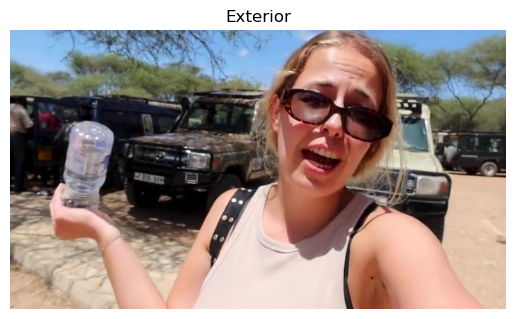

image shape: (480, 854, 3)


In [9]:
img = random_img(root_path / "train", class_names[0])

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_dir = root_path / "train"
test_dir = root_path / "test"
val_dir = root_path / "val"

In [12]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode='binary')
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode='binary')
val_data = val_datagen.flow_from_directory(val_dir,
                                           batch_size=32,
                                           target_size=(224, 224),
                                           class_mode='binary')









Found 1620 images belonging to 2 classes.


Found 200 images belonging to 2 classes.
Found 180 images belonging to 2 classes.


In [13]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                          kernel_size=3,
                          activation='relu',
                          input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, 
                              padding='valid'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(loss='binary_crossentropy',
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['accuracy'])

baseline_model.loss = baseline_model.fit(train_data,
                                          epochs=5,
                                          steps_per_epoch=len(train_data),
                                          validation_data=val_data,
                                          validation_steps=len(val_data))


                        

/home/smuguis/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760050954.237249   12316 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6102 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:2d:00.0, compute capability: 7.5
/home/smuguis/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called(

Epoch 1/5


2025-10-10 01:02:36.579584: I external/local_xla/xla/service/service.cc:163] XLA service 0x797750007b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-10 01:02:36.579628: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2025-10-10 01:02:36.621743: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-10 01:02:36.927079: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-10 01:02:37.252414: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,10,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[10,3,3,3]{3,2,1,0}, f32[10]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_targe

 3/51 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.5208 - loss: 0.6850

I0000 00:00:1760050960.537086   12537 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/51 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.5503 - loss: 0.6798

2025-10-10 01:02:43.711769: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,10,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,224,224]{3,2,1,0}, f32[10,3,3,3]{3,2,1,0}, f32[10]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-10 01:02:43.938474: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,10,220,220]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,10,222,222]{3,2,1,0}, f32[10,10,3,3]{3,2,1,0}, f32[10]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5798 - loss: 0.6625

2025-10-10 01:02:50.163840: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,10,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[10,3,3,3]{3,2,1,0}, f32[10]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-10 01:02:50.417091: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,10,220,220]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,10,222,222]{3,2,1,0}, f32[10,10,3,3]{3,2,1,0}, f32[10]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step - accuracy: 0.6290 - loss: 0.6305 - val_accuracy: 0.7222 - val_loss: 0.5304
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.7383 - loss: 0.5158 - val_accuracy: 0.8000 - val_loss: 0.4445
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.8086 - loss: 0.4282 - val_accuracy: 0.7944 - val_loss: 0.4078
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.8648 - loss: 0.3390 - val_accuracy: 0.8000 - val_loss: 0.4215
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.8944 - loss: 0.2706 - val_accuracy: 0.8389 - val_loss: 0.3604


In [14]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

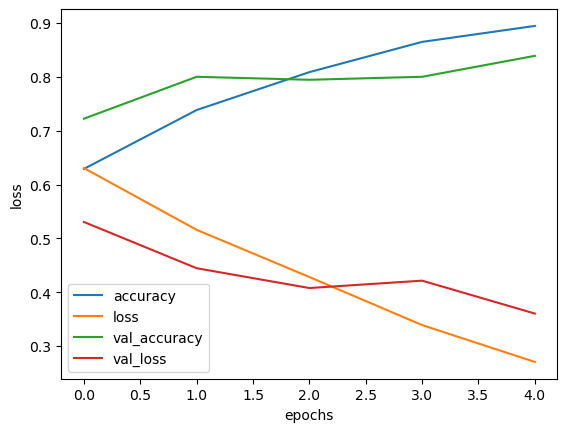

In [15]:
pd.DataFrame(baseline_model.history.history).plot()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()




In [17]:
train_datagen_augmented = ImageDataGenerator(rescale=1./255,
                                             rotation_range=20,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True,
                                             vertical_flip=True)

test_data = ImageDataGenerator(rescale=1./255)
val_data = ImageDataGenerator(rescale=1./255)


In [18]:
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   batch_size=32,
                                                                   target_size=(224, 224),
                                                                   class_mode='binary', 
                                                                   shuffle=True)

test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode='binary')

val_data = val_datagen.flow_from_directory(val_dir,
                                           batch_size=32,
                                           target_size=(224, 224),
                                           class_mode='binary')






Found 1620 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 180 images belonging to 2 classes.


In [20]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

model_1_loss = model_1.fit(train_data_augmented,
                           epochs=5,
                           steps_per_epoch=len(train_data_augmented),
                           validation_data=val_data,
                           validation_steps=len(val_data))




/home/smuguis/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/smuguis/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.5741 - loss: 0.6777 - val_accuracy: 0.7111 - val_loss: 0.6451
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.6969 - loss: 0.5857 - val_accuracy: 0.7222 - val_loss: 0.4865
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.7031 - loss: 0.5515 - val_accuracy: 0.8222 - val_loss: 0.4449
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.7204 - loss: 0.5401 - val_accuracy: 0.6556 - val_loss: 0.5735
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 293ms/step - accuracy: 0.7500 - loss: 0.4970 - val_accuracy: 0.8278 - val_loss: 0.3957


In [21]:
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

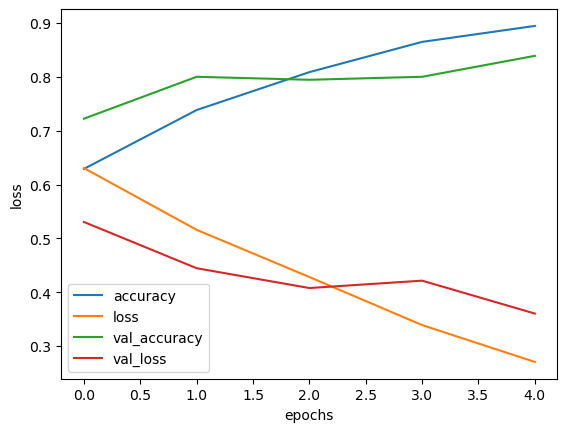

In [22]:
pd.DataFrame(baseline_model.history.history).plot()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

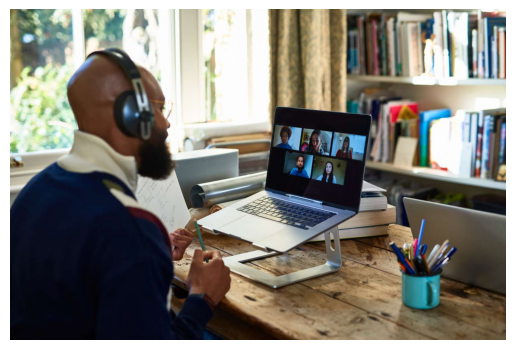

In [40]:
img_path = "/home/smuguis/development/datasets/data/home_office.jpg"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()






In [41]:

img_path = "/home/smuguis/development/datasets/data/home_office.jpg"

x = tf.io.read_file(img_path)
x = tf.image.decode_image(x, channels=3, expand_animations=False)  # -> uint8
x = tf.image.resize(x, (224, 224))
x = tf.cast(x, tf.float32) / 255.0
x = tf.expand_dims(x, 0)  # (1,224,224,3)

pred = model_1.predict(x)

if pred > 0.5:
    print("This is an interior image")
else:
    print("This is an exterior image")
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This is an interior image
